Found 3901 images in ../../Datasets/DSEC_Detection/dsec-det/test_images/test/thun_02_a/images/left/rectified
Loaded 3901 exposure timestamps from ../../Datasets/DSEC_Detection/dsec-det/test_images/test/thun_02_a/images/left/exposure_timestamps.txt
Displaying image: 000890.png with timestamp: 50281500981 μs
Found 16 detections within tolerance of image timestamp.


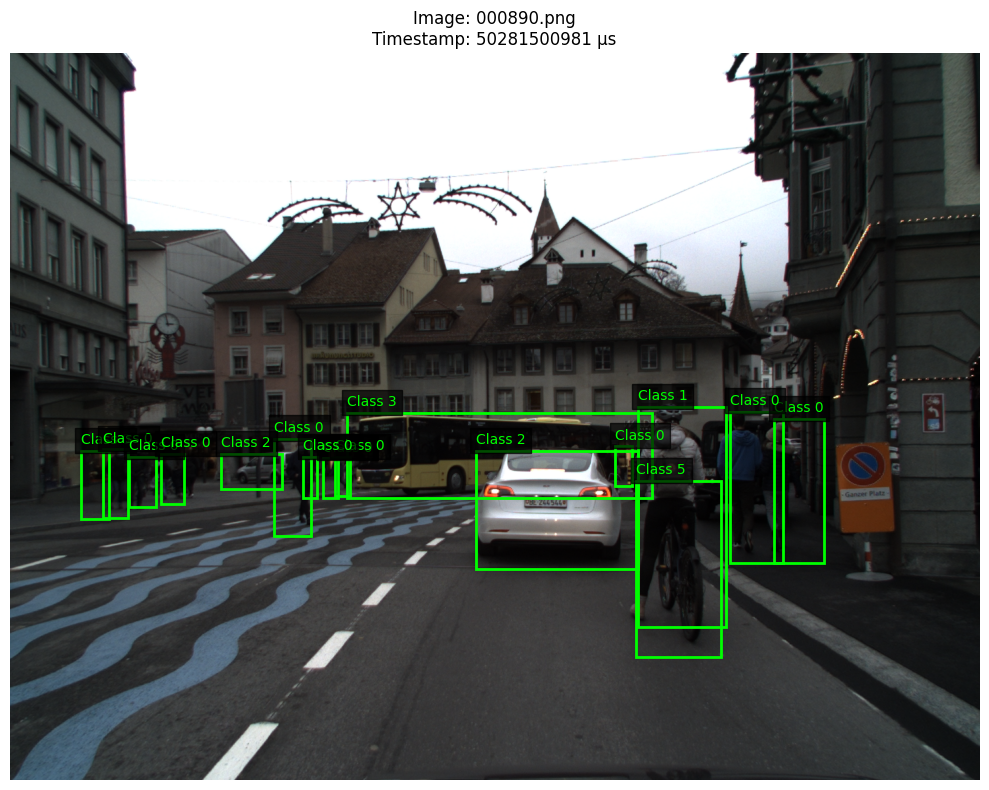

In [43]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import random

# ===== Environment Setup =====
os.environ["HDF5_USE_FILE_LOCKING"] = "FALSE"

# ===== Path Configuration =====
base_dir = "../../Datasets/DSEC_Detection"
split = "test"       # or "train"
sequence = "thun_02_a"  # Example sequence

# Object detection labels (provided as a single file "tracks.npy")
label_dir = os.path.join(base_dir, "dsec-det", f"{split}_object_detections", split, sequence, "object_detections", "left")
label_file = os.path.join(label_dir, "tracks.npy")

# Test images folder structure:
# ../../Datasets/DSEC_Detection/dsec-det/test_images/test/thun_02_a/images/left/
# ├─ exposure_timestamps.txt
# └─ rectified (contains PNG images)
images_base_dir = os.path.join(base_dir, "dsec-det", f"{split}_images", split, sequence, "images", "left")
left_image_dir = os.path.join(images_base_dir, "rectified")
timestamps_file = os.path.join(images_base_dir, "exposure_timestamps.txt")

# ===== Helper Functions =====
def list_files(directory, extension=""):
    if not os.path.exists(directory):
        return []
    return sorted([os.path.join(directory, f) for f in os.listdir(directory) if f.endswith(extension)])

def load_exposure_timestamps(file_path):
    """
    Load exposure timestamps from a file with lines:
      exposure_start_timestamp_us, exposure_end_timestamp_us
    Compute the mid-exposure time for each image.
    Returns a list of mid-exposure timestamps.
    """
    timestamps = []
    with open(file_path, 'r') as f:
        for line in f:
            line = line.strip()
            if line.startswith("#") or not line:
                continue
            parts = line.split(",")
            if len(parts) < 2:
                continue
            start_ts = int(parts[0].strip())
            end_ts = int(parts[1].strip())
            mid_ts = (start_ts + end_ts) // 2
            timestamps.append(mid_ts)
    return timestamps

# ===== Data Loading =====
# List image files from the "rectified" folder
image_files = list_files(left_image_dir, ".png")
print(f"Found {len(image_files)} images in {left_image_dir}")

# Load exposure timestamps
exposure_timestamps = load_exposure_timestamps(timestamps_file)
print(f"Loaded {len(exposure_timestamps)} exposure timestamps from {timestamps_file}")

if len(image_files) != len(exposure_timestamps):
    raise ValueError("Mismatch between number of image files and exposure timestamps")

# ===== Load Labels =====
if not os.path.exists(label_file):
    raise FileNotFoundError(f"Label file not found: {label_file}")

labels = np.load(label_file, allow_pickle=True)
expected_keys = ('t', 'x', 'y', 'w', 'h', 'class_id', 'class_confidence', 'track_id')
if labels.dtype.names != expected_keys:
    raise ValueError(f"Unexpected label structure: {labels.dtype.names}, expected {expected_keys}")

# ===== Visualization =====
# For demonstration, select a random image (and its corresponding exposure timestamp)
random_idx = random.randint(0, len(image_files) - 1)
img_path = image_files[random_idx]
img_timestamp = exposure_timestamps[random_idx]
print(f"Displaying image: {os.path.basename(img_path)} with timestamp: {img_timestamp} μs")

# Filter labels that occur within a given tolerance of the image's timestamp
tolerance = 100  # microseconds; adjust as needed
filtered_labels = [det for det in labels if abs(det['t'] - img_timestamp) <= tolerance]
print(f"Found {len(filtered_labels)} detections within tolerance of image timestamp.")

# Define scaling factors from event sensor (640x480) to image resolution (1440x1080)
scale_x = 1440 / 640  # =2.25
scale_y = 1080 / 480  # =2.25



# Load the image using PIL
img = Image.open(img_path)
plt.figure(figsize=(12, 8))
plt.imshow(img)

# Draw the filtered detections (scaled)
for det in filtered_labels:
    # Extract original detection coordinates (from 640x480 space)
    x, y, w, h = det['x'], det['y'], det['w'], det['h']
    class_id = det['class_id']
    
    # Scale coordinates to image resolution
    x_img = x * scale_x
    y_img = y * scale_y
    w_img = w * scale_x
    h_img = h * scale_y
    
    offset_x = 35  # experiment with this value
    offset_y = -100  # experiment with this value

    x_img = x * scale_x - offset_x
    y_img = y * scale_y - offset_y
    
    rect = plt.Rectangle((x_img, y_img), w_img, h_img,
                         fill=False, edgecolor='lime', linewidth=2)
    plt.gca().add_patch(rect)
    plt.text(x_img, y_img - 10, f'Class {class_id}', color='lime', fontsize=10,
             bbox=dict(facecolor='black', alpha=0.7))

plt.title(f"Image: {os.path.basename(img_path)}\nTimestamp: {img_timestamp} μs")
plt.axis("off")
plt.tight_layout()
plt.show()

In [ ]:
import os
import numpy as np
import h5py
import hdf5plugin
import torch
from torch.utils.data import Dataset

class EventFrameDataset(Dataset):
    def __init__(self, event_file, label_file, transform=None, num_events_per_sample=500):
        """
        Args:
            event_file: Path to the HDF5 event file (e.g., events.h5)
            label_file: Path to the corresponding labels file (e.g., tracks.npy)
            transform: Any additional transforms (e.g., normalization)
            num_events_per_sample: Fixed number of events per sample
        """
        self.event_file = event_file  # Single HDF5 file
        self.labels = np.load(label_file, allow_pickle=True)  # Load the labels
        self.transform = transform
        self.num_events_per_sample = num_events_per_sample  # Fixed number of events per sample

        # Open HDF5 file and read event timestamps
        with h5py.File(self.event_file, "r") as f:
            self.t_offset = f["t_offset"][()]  # Time offset correction
            print(f"🕒 Loaded time offset: {self.t_offset}")

            self.event_data = {
                "t": f["events/t"][:] + self.t_offset,  # Apply offset
                "x": f["events/x"][:],
                "y": f["events/y"][:],
                "p": f["events/p"][:]
            }

        # Print event timestamp range
        print(f"📊 Event timestamps range: {self.event_data['t'].min()} → {self.event_data['t'].max()}")

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        label = self.labels[idx]
        label_timestamp = label['t']  # Timestamp of detection (expected in µs)


        if label_timestamp < 1e9: 
            print(f"Warning: Label timestamp {label_timestamp} looks like it's in ms, converting to µs")
            label_timestamp *= 1000  # Convert ms → µs

        print(f"\n🕒 Looking for events around timestamp: {label_timestamp} µs")

        # 🔥 Expand event search window
        event_indices = np.where((self.event_data["t"] >= label_timestamp - 10000) &  # ±10ms window
                                 (self.event_data["t"] <= label_timestamp + 10000))[0]

        if len(event_indices) == 0:
            print(f"⚠️ No events found for timestamp {label_timestamp}. Using zero-padding.")
            events_x = np.zeros(self.num_events_per_sample)
            events_y = np.zeros(self.num_events_per_sample)
            events_p = np.zeros(self.num_events_per_sample)
            events_t = np.zeros(self.num_events_per_sample)
        else:
            event_indices = event_indices[:self.num_events_per_sample]  # Select fixed number of events
            events_x = self.event_data["x"][event_indices]
            events_y = self.event_data["y"][event_indices]
            events_p = self.event_data["p"][event_indices]
            events_t = self.event_data["t"][event_indices]

        # ✅ Ensure x, y values are correctly scaled
        scale_x = 640 / 1440  
        scale_y = 480 / 1080
        events_x = events_x * scale_x
        events_y = events_y * scale_y

        # ✅ Convert to efficient format
        event_data_np = np.stack([events_x, events_y, events_p, events_t], axis=0)  # Shape: (4, num_events)
        event_tensor = torch.tensor(event_data_np, dtype=torch.float32)
        label_tensor = torch.tensor(label["class_id"], dtype=torch.long)  # Use class_id for classification

        return event_tensor, label_tensor

In [20]:
import torch
import torch.nn as nn
import snntorch as snn
import snntorch.functional as SF
import snntorch.surrogate as surrogate

class SimpleSNN(nn.Module):
    def __init__(self, num_classes=10):
        super(SimpleSNN, self).__init__()
        self.conv1 = nn.Conv2d(2, 16, kernel_size=3, padding=1)
        self.lif1 = snn.Leaky(beta=0.9, spike_grad=surrogate.fast_sigmoid())
        self.pool = nn.AvgPool2d(2)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.lif2 = snn.Leaky(beta=0.9, spike_grad=surrogate.fast_sigmoid())
        self.fc = nn.Linear(32 * 28 * 28, num_classes)  # adjust dimensions based on input size

    def forward(self, x):
        # x shape: [B, C, H, W]
        x = self.conv1(x)
        spk, mem = self.lif1(x)
        x = self.pool(spk)
        x = self.conv2(x)
        spk, mem = self.lif2(x)
        x = self.pool(spk)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

In [ ]:

import torch.optim as optim
from torch.utils.data import DataLoader
import hdf5plugin

# Hyperparameters
batch_size = 32
num_epochs = 10
learning_rate = 1e-3

# Paths for training data (use one of the train sequences, e.g., zurich_city_16_a)
# Assume you have preprocessed event frames and a labels file for training
train_event_file = "../../Datasets/DSEC_Detection/dsec-det/train_events/train/zurich_city_17_a/events/left/events.h5"
train_label_file = "../../Datasets/DSEC_Detection/dsec-det/train_object_detections/train/zurich_city_17_a/object_detections/left/tracks.npy"

train_dataset = EventFrameDataset(train_event_file, train_label_file)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
# Create dataset and dataloader

# Initialize model, loss, optimizer
model = SimpleSNN(num_classes=10)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# Training loop
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

for epoch in range(num_epochs):
    running_loss = 0.0
    for batch_x, batch_y in train_loader:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)
        
        optimizer.zero_grad()
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * batch_x.size(0)
    epoch_loss = running_loss / len(train_dataset)
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {epoch_loss:.4f}")

print("Training complete.")

In [ ]:
import os
import numpy as np
import h5py

print("\n🔎 DATASET VERIFICATION (Relative Timestamp Alignment)")

# Assume train_dataset is already loaded with:
# - train_dataset.labels: the label array from tracks.npy
# - train_dataset.event_data: a dict with keys "t", "x", "y", "p" from events.h5

# Print the original min/max ranges (absolute timestamps)
min_label_time = train_dataset.labels["t"].min()
max_label_time = train_dataset.labels["t"].max()
min_event_time = train_dataset.event_data["t"].min()
max_event_time = train_dataset.event_data["t"].max()

print("\n Original Absolute Timestamp Ranges:")
print("    Label timestamp range: {} → {} µs".format(min_label_time, max_label_time))
print("    Event timestamp range: {} → {} µs".format(min_event_time, max_event_time))

# Compute and print t_offset (should already be applied to events)
# Note: t_offset is loaded when the dataset is initialized (if available)
try:
    t_offset = train_dataset.t_offset
    print("\n Loaded t_offset: {}".format(t_offset))
except AttributeError:
    print("\n t_offset not found in dataset. Using 0.")
    t_offset = 0

# Align both timestamps to a common reference (the minimum event timestamp)
relative_event_timestamps = train_dataset.event_data["t"] - min_event_time
relative_label_timestamps = train_dataset.labels["t"] - min_event_time

print("\n Relative Timestamp Ranges (Reference = min_event_time):")
print("    Relative Label timestamp range: {} → {} µs".format(
    relative_label_timestamps.min(), relative_label_timestamps.max()))
print("    Relative Event timestamp range: {} → {} µs".format(
    relative_event_timestamps.min(), relative_event_timestamps.max()))

# Compute the relative offset between the labels and events
relative_offset = relative_label_timestamps.min()  # first label relative time
print("\n Relative offset (first label): {} µs".format(relative_offset))
print("This means that the labels occur about {} µs after the first event.".format(relative_offset))

# For further debug: Compare medians of the two distributions
median_label = np.median(relative_label_timestamps)
median_event = np.median(relative_event_timestamps)
print("\n Median Relative Timestamps:")
print("    Median label timestamp: {} µs".format(median_label))
print("    Median event timestamp: {} µs".format(median_event))

print("\n Debugging complete. Use these relative timestamps to match events to labels.")


🔎 DATASET VERIFICATION (Relative Timestamp Alignment)

📊 Original Absolute Timestamp Ranges:
    Label timestamp range: 38324150356 → 38351601040 µs
    Event timestamp range: 38278001119 → 38354600923 µs

🕒 Loaded t_offset: 38277999980

📊 Relative Timestamp Ranges (Reference = min_event_time):
    Relative Label timestamp range: 46149237 → 73599921 µs
    Relative Event timestamp range: 0 → 76599804 µs

⚠️ Relative offset (first label): 46149237 µs
This means that the labels occur about 46149237 µs after the first event.

📊 Median Relative Timestamps:
    Median label timestamp: 64424456.5 µs
    Median event timestamp: 50084419.0 µs

✅ Debugging complete. Use these relative timestamps to match events to labels.


🕒 Loaded `t_offset`: 38277999980

📊 Timestamp Ranges (Corrected):
   Labels: 46150376 → 73601060
   Events: 1139 → 76600943

🎯 Selected Label Timestamp: 66450734

🔍 Unique Label Timestamps: 452 unique timestamps
🔎 Most common label timestamps:
 {46150376: 1, 46200384: 1, 46250385: 1, 46300382: 1, 46350384: 1, 46400389: 1, 46450395: 1, 46500419: 1, 46550413: 1, 46600416: 1}
🔎 Found 191449 events in ±10000 µs range.


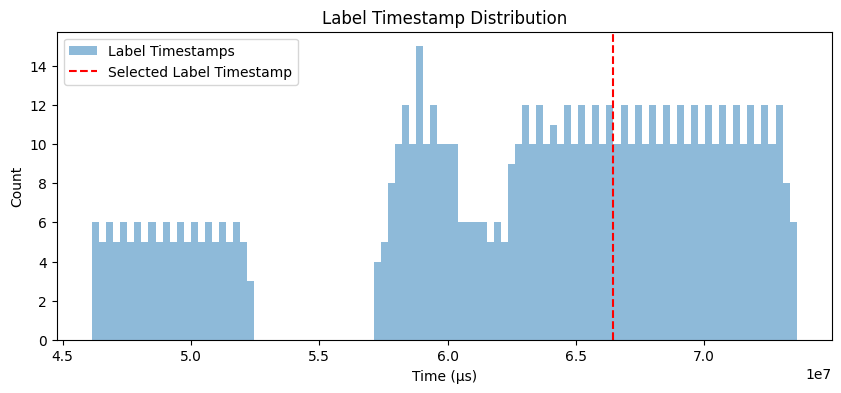


🔎 Checking Raw Labels Before Scaling:
Label 1: x=541.0, y=217.0, w=47.0, h=28.0 | Class: 2
Label 2: x=545.0, y=217.0, w=49.0, h=30.0 | Class: 2
Label 3: x=548.0, y=218.0, w=53.0, h=28.0 | Class: 2
Label 4: x=550.0, y=218.0, w=57.0, h=30.0 | Class: 2
Label 5: x=553.0, y=218.0, w=59.0, h=28.0 | Class: 2
🔎 Original Box: x=180.0, y=200.0, w=30.0, h=18.0
✅ Scaled Box: x=180, y=200, w=30, h=18
🔎 Original Box: x=144.0, y=198.0, w=29.0, h=22.0
✅ Scaled Box: x=144, y=198, w=29, h=22

✅ Total Bounding Boxes Drawn: 2


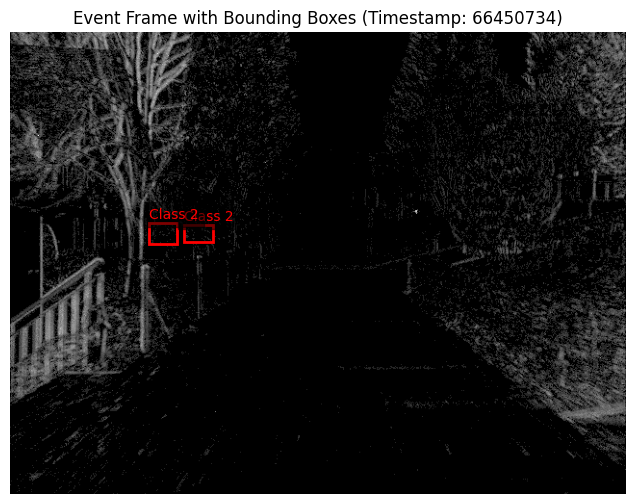

In [ ]:
#Success Below!

🕒 Loaded `t_offset`: 54812999957
🔍 Unique Tracks Available: [  0   1   2   5   6   8   9  10  12  13  14  18  19  20  21  22  23  25
  27  28  29  31  32  33  34  35  36  37  40  41  42  45  47  48  49  51
  52  54  55  57  58  59  60  61  62  63  67  68  70  71  72  78  80  82
  84  85  86  88  90  91  94  97  98  99 100 101 102 105 106 107 108 111
 112 114 116 117 119 122 123 126 127 128 131 132 138 142 144 145 146 147
 148 150 151 152 156 157 161]

🎯 Selected Base Label Timestamp: 11657587
🔎 Found 6 matching labels in ±20000 µs range.
🔎 Found 281107 events in ±20000 µs range.

🔎 Checking Multiple Labels Before Scaling:
🔎 Label 1: Track 20 | Class 0 | x=383, y=189, w=14, h=35
🔎 Label 2: Track 1 | Class 2 | x=3, y=233, w=40, h=26
🔎 Label 3: Track 2 | Class 2 | x=-3, y=233, w=24, h=23
🔎 Label 4: Track 14 | Class 5 | x=456, y=211, w=55, h=35
🔎 Label 5: Track 21 | Class 5 | x=641, y=203, w=34, h=39
🔎 Label 6: Track 12 | Class 5 | x=536, y=203, w=35, h=41


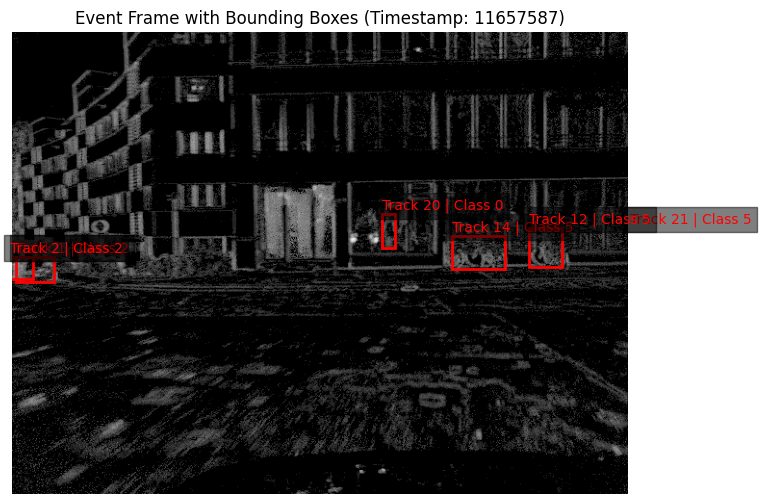

In [ ]:
import numpy as np
import h5py
import matplotlib.pyplot as plt
import random

# ==========================
# 🔍 Load Event Data & Labels
# ==========================
event_file = "../../Datasets/DSEC_Detection/dsec-det/train_events/train/zurich_city_18_a/events/left/events.h5"
label_file = "../../Datasets/DSEC_Detection/dsec-det/train_object_detections/train/zurich_city_18_a/object_detections/left/tracks.npy"

# Load labels (bounding boxes)
labels = np.load(label_file, allow_pickle=True)

# Open HDF5 file
with h5py.File(event_file, "r") as f:
    event_data = {
        "t": f["events/t"][:],  
        "x": f["events/x"][:],  
        "y": f["events/y"][:],  
        "p": f["events/p"][:]   
    }
    t_offset = f["t_offset"][()] if "t_offset" in f else 0  # Handle missing offsets

print(f"🕒 Loaded `t_offset`: {t_offset}")

# ==========================
# ⏳ Correct Time Alignment
# ==========================
labels_corrected = labels.copy()
labels_corrected["t"] -= t_offset  # Shift timestamps by t_offset

# Check track IDs
unique_tracks = np.unique(labels_corrected["track_id"])
print(f"🔍 Unique Tracks Available: {unique_tracks}")

# ==========================
# 🎯 Select Multiple Labels in a Time Window
# ==========================
time_window = 20000  # ±20ms

# Randomly select a base timestamp
random_idx = random.randint(0, len(labels_corrected) - 1)
base_label_timestamp = labels_corrected[random_idx]["t"]

# Select all labels within the time window
matching_labels = labels_corrected[
    (labels_corrected["t"] >= base_label_timestamp - time_window) &
    (labels_corrected["t"] <= base_label_timestamp + time_window)
]

print(f"\n🎯 Selected Base Label Timestamp: {base_label_timestamp}")
print(f"🔎 Found {len(matching_labels)} matching labels in ±{time_window} µs range.")

# ==========================
# 🛠 Expand Event Search Window
# ==========================
event_indices = np.where(
    (event_data["t"] >= base_label_timestamp - time_window) &
    (event_data["t"] <= base_label_timestamp + time_window)
)[0]

print(f"🔎 Found {len(event_indices)} events in ±{time_window} µs range.")

# ==========================
# ⚠️ Handle No Event Matches
# ==========================
if len(event_indices) == 0:
    print("⚠️ No events found. Consider checking timestamp alignment or increasing time window.")
else:
    # ==========================
    # 🎨 Generate Event Frame
    # ==========================
    event_frame = np.zeros((480, 640))  # Assuming 640x480 event sensor resolution

    for idx in event_indices:
        x, y = event_data["x"][idx], event_data["y"][idx]
        event_frame[y, x] += 1  # Accumulate event count

    # Normalize for visualization
    event_frame = np.log1p(event_frame)
    event_frame = (event_frame / np.max(event_frame)) * 255 if np.max(event_frame) > 0 else event_frame
    event_frame = event_frame.astype(np.uint8)^

    # ==========================
    # 📸 Visualize Event Frame
    # ==========================
    plt.figure(figsize=(10, 6))
    plt.imshow(event_frame, cmap="gray")

    # ==========================
    # 🏷 Overlay Bounding Boxes for All Labels
    # ==========================
    print("\n🔎 Checking Multiple Labels Before Scaling:")
    scale_x = 1  # Scale down if necessary
    scale_y = 1  

    for i, det in enumerate(matching_labels):  
        x, y, w, h = det["x"], det["y"], det["w"], det["h"]
        track_id = det["track_id"]
        class_id = det["class_id"]

        # Apply correct scaling to match the event frame
        x_scaled, y_scaled = int(x * scale_x), int(y * scale_y)
        w_scaled, h_scaled = int(w * scale_x), int(h * scale_y)

        # Debug: Check bounding box positions
        print(f"🔎 Label {i+1}: Track {track_id} | Class {class_id} | x={x_scaled}, y={y_scaled}, w={w_scaled}, h={h_scaled}")

        # Draw bounding box
        rect = plt.Rectangle((x_scaled, y_scaled), w_scaled, h_scaled, 
                             fill=False, edgecolor="red", linewidth=2)
        plt.gca().add_patch(rect)
        plt.text(x_scaled, y_scaled - 5, f"Track {track_id} | Class {class_id}", 
                 color="red", fontsize=10, bbox=dict(facecolor="black", alpha=0.5))

    plt.title(f"Event Frame with Bounding Boxes (Timestamp: {base_label_timestamp})")
    plt.axis("off")
    plt.show()

In [7]:
import h5py
import hdf5plugin

with h5py.File("../../Datasets/DSEC_Detection/dsec-det/train_events/train/zurich_city_17_a/events/left/events.h5", "r") as f:
    print("HDF5 file opened successfully!")
    print("Keys:", list(f.keys()))

HDF5 file opened successfully!
Keys: ['events', 'ms_to_idx', 't_offset']


## SNN training implementation for above

🕒 Loaded `t_offset`: 54812999957
🔍 Unique Tracks Available: [  0   1   2   5   6   8   9  10  12  13  14  18  19  20  21  22  23  25
  27  28  29  31  32  33  34  35  36  37  40  41  42  45  47  48  49  51
  52  54  55  57  58  59  60  61  62  63  67  68  70  71  72  78  80  82
  84  85  86  88  90  91  94  97  98  99 100 101 102 105 106 107 108 111
 112 114 116 117 119 122 123 126 127 128 131 132 138 142 144 145 146 147
 148 150 151 152 156 157 161]
🎯 Base Timestamp: 43755926, 🔎 7 matching labels
🔎 Found 279338 events


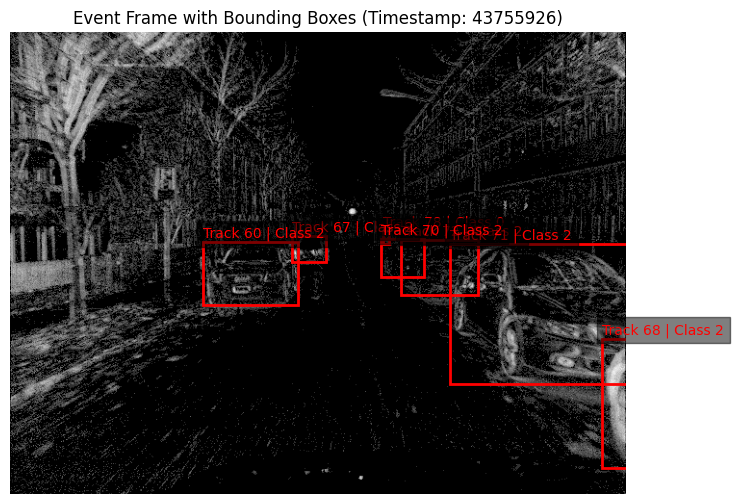

In [ ]:


# ==========================
# Load Event Data & Labels
# ==========================
event_file = "../../Datasets/DSEC_Detection/dsec-det/train_events/train/zurich_city_18_a/events/left/events.h5"
label_file = "../../Datasets/DSEC_Detection/dsec-det/train_object_detections/train/zurich_city_18_a/object_detections/left/tracks.npy"

# Load labels (bounding boxes)
labels = np.load(label_file, allow_pickle=True)

# Open HDF5 file
with h5py.File(event_file, "r") as f:
    event_data = {key: f["events/" + key][:] for key in ["t", "x", "y", "p"]}
    t_offset = f.get("t_offset", 0)[()]

print(f"Loaded `t_offset`: {t_offset}")


labels["t"] -= t_offset
print(f"Unique Tracks Available: {np.unique(labels['track_id'])}")

# ==========================
# Select Labels in a Time Window
# ==========================
time_window = 10000  # ±20ms
base_label_timestamp = random.choice(labels)["t"]
matching_labels = labels[(labels["t"] >= base_label_timestamp - time_window) & (labels["t"] <= base_label_timestamp + time_window)]

print(f"🎯 Base Timestamp: {base_label_timestamp}, 🔎 {len(matching_labels)} matching labels")


event_indices = np.where((event_data["t"] >= base_label_timestamp - time_window) & (event_data["t"] <= base_label_timestamp + time_window))[0]
print(f"🔎 Found {len(event_indices)} events")

if not len(event_indices):
    print("No events found. Adjust timestamp alignment or increase time window.")
    exit()

event_frame = np.zeros((480, 640))
np.add.at(event_frame, (event_data["y"][event_indices], event_data["x"][event_indices]), 1)

# Normalize for visualization
event_frame = (np.log1p(event_frame) / np.log1p(event_frame.max()) * 255).astype(np.uint8) if event_frame.max() > 0 else event_frame

plt.figure(figsize=(10, 6))
plt.imshow(event_frame, cmap="gray")

for det in matching_labels:
    rect = plt.Rectangle((det["x"], det["y"]), det["w"], det["h"], fill=False, edgecolor="red", linewidth=2)
    plt.gca().add_patch(rect)
    plt.text(det["x"], det["y"] - 5, f"Track {det['track_id']} | Class {det['class_id']}", color="red", fontsize=10, bbox=dict(facecolor="black", alpha=0.5))

plt.title(f"Event Frame with Bounding Boxes (Timestamp: {base_label_timestamp})")
plt.axis("off")
plt.show()
